# Graph Neural Network - Edge prediction on Cora dataset

This notebook aims at training and tesing edge prediction on Cora dataset. The notebook includes the following tasks:  
1. Preprocess the dataset and formulate the edge prediction task.  
2. Implement the DNN-based edge prediction model.  
3. Implement the GNN-based edge prediction model.  
4. Train and evaluate both models, computing the necessary metrics.  


The Cora dataset consists of 2708 scientific publications classified into one of seven classes. The citation network consists of 5429 links. Each publication in the dataset is described by a 0/1-valued word vector indicating the absence/presence of the corresponding word from the dictionary. The dictionary consists of 1433 unique words. More details can be found at https://graphsandnetworks.com/the-cora-dataset/.

# CORA dataset download and processing

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping

### Dataset download

In [ ]:
zip_file = keras.utils.get_file(
    fname="cora.tgz",
    origin="https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz",
    extract=True,
    cache_dir="/content",
    cache_subdir="")

In [ ]:
!mkdir -p /content/cora_extracted
!tar -xvzf /content/cora.tgz -C /content/cora_extracted
data_dir = "/content/cora_extracted/cora"
# Load cora.cites
citations = pd.read_csv(
    os.path.join(data_dir, "cora.cites"),
    sep="\t",
    header=None,
    names=["target", "source"]
)
# Load cora.content (node features + labels)
content = pd.read_csv(
    os.path.join(data_dir, "cora.content"),
    sep="\t",
    header=None
)

cora/
cora/README
cora/cora.cites
cora/cora.content


In [ ]:
# Read cora.content — this file contains descriptions of the papers
column_names = ["paper_id"] + [f"word_{idx}" for idx in range(1433)] + ["subject"]

# Load the paper features and labels
papers = pd.read_csv(
    os.path.join(data_dir, "cora.content"),
    sep="\t",
    header=None,
    names=column_names
)

# Print some paper samples
print("Papers shape:", papers.shape)
print("\nSample papers:\n", papers.sample(n=10))

Papers shape: (2708, 1435)

Sample papers:
       paper_id  word_0  word_1  word_2  word_3  word_4  word_5  word_6  \
1056   1130680       0       0       0       0       0       0       0   
2035   1107367       0       1       0       0       0       0       0   
1435   1152714       0       0       0       0       0       0       0   
2031     23545       0       0       0       0       0       0       0   
2621    610529       0       0       0       0       0       0       0   
64      310530       0       0       0       0       0       0       0   
2366    633585       0       0       0       0       0       0       0   
2450    263486       0       0       0       0       0       0       0   
907    1130568       0       0       0       0       0       0       0   
329    1152569       0       0       0       0       0       0       0   

      word_7  word_8  ...  word_1424  word_1425  word_1426  word_1427  \
1056       0       0  ...          0          0          0          

## Generate new mapping for paper index and subject index

In [ ]:
# Get list of unique paper subjects / classes. These are the labels for Node (Paper) Classification.
class_values = sorted(papers["subject"].unique())

# Generate corresponding list of unique class indices
class_idx = {name: idx for idx, name in enumerate(class_values)}

# Generate list of unique class indices
paper_idx = {name: idx for idx, name in enumerate(sorted(papers["paper_id"].unique()))}

In [ ]:
### Map the original papers and citations information (paper_idx and class_idx) to the new information

# Map original paper index to the new paper index
papers["paper_id"] = papers["paper_id"].apply(lambda name: paper_idx[name])

# Map original paper subject (string) to the new paper subject (integer)
papers["subject"] = papers["subject"].apply(lambda value: class_idx[value])

# Map original source/target paper index to the new source/target paper index
citations["source"] = citations["source"].apply(lambda name: paper_idx[name])
citations["target"] = citations["target"].apply(lambda name: paper_idx[name])

In [ ]:
# Print some citation samples with new index mapping
print("Citations shape:", citations.shape)
citations.sample(n=10)

Citations shape: (5429, 2)


,target,source
4218,1042,1704
2749,467,1688
2644,436,120
3877,855,2282
4751,1338,2163
4289,1082,2582
3406,675,381
5380,1843,2554
2291,340,2268
2497,386,578


In [ ]:
# Print some citation samples with new index mapping
print("Papers shape:", papers.shape)
papers.sample(n=10)

Papers shape: (2708, 1435)


,paper_id,word_0,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,...,word_1424,word_1425,word_1426,word_1427,word_1428,word_1429,word_1430,word_1431,word_1432,subject
35,263,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
2707,376,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
246,1296,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
1422,512,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1650,1564,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
779,1529,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1857,546,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,3
2202,1503,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
749,427,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
1872,2402,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


##Preprocess the dataset and formulate the edge prediction task

In [ ]:
import random
# Total number of nodes
num_nodes = len(papers)
# Get the existing positive edges
positive_edges = citations[["source", "target"]].to_numpy()

# Convert existing edges to a set
positive_edge_set = set(map(tuple, positive_edges))
positive_edge_set |= set((j, i) for (i, j) in positive_edge_set)

# Initialize negative edges list
negative_edges = set()

# Keep generating until we have the same number of negatives as positives
while len(negative_edges) < len(positive_edges):
    i = random.randint(0, num_nodes - 1)
    j = random.randint(0, num_nodes - 1)

    if i == j:
        continue
    if (i, j) in positive_edge_set or (j, i) in positive_edge_set:
        continue
    if (i, j) in negative_edges or (j, i) in negative_edges:
        continue

    negative_edges.add((i, j))

# Convert to NumPy array
negative_edges = np.array(list(negative_edges))


In [ ]:
node_features = papers.drop(columns=["subject"]).sort_values(by="paper_id").drop(columns=["paper_id"]).to_numpy()


def create_edge_features(edges, node_features):
    return np.hstack([node_features[edges[:, 0]], node_features[edges[:, 1]]])

# Create feature vectors for both sets
X_pos = create_edge_features(positive_edges, node_features)
X_neg = create_edge_features(negative_edges, node_features)

# Create labels
y_pos = np.ones(len(X_pos))
y_neg = np.zeros(len(X_neg))

# Combine into one dataset
X = np.vstack([X_pos, X_neg])
y = np.hstack([y_pos, y_neg])

In [ ]:
# Shuffle and Split the Dataset
from sklearn.model_selection import train_test_split

# First, shuffle
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

# Split into train, validation, and test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (7600, 2866), Val: (1629, 2866), Test: (1629, 2866)


## DNN-based edge prediction model

In [ ]:
from tensorflow.keras import regularizers
# Feed Forward Network setup: number of FC layers and number of nodes in each FC layer
hidden_units = [32, 32]
dropout_rate = 0.3

# Create a Feed Forward Network (FFN) as a Sequential model
def create_ffn(hidden_units_ffn, dropout_rate_ffn):
    fnn_layers = []
    for units in hidden_units_ffn:
        fnn_layers.extend([
            layers.Dense(units, activation=tf.nn.gelu, kernel_regularizer=keras.regularizers.l2(0.001)),
            layers.Dropout(dropout_rate_ffn),
            layers.BatchNormalization()
        ])
    return keras.Sequential(fnn_layers)


# Create a Deep Neural Network (DNN) for node classification
def create_dnn_model(hidden_units_ffn, dropout_rate_ffn, model_name):
    inputs = layers.Input(shape=(2866,))

    # Initial feature transformation
    x = create_ffn(hidden_units_ffn, dropout_rate_ffn)(inputs)

    for block_idx in range(4):
        x1 = create_ffn(hidden_units_ffn, dropout_rate_ffn)(x)
        x = layers.Add()([x, x1])
        x = layers.BatchNormalization()(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs=inputs, outputs=outputs, name=model_name)

dnn_model = create_dnn_model(hidden_units, dropout_rate, "DNN")
dnn_model.summary()

Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2866)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 32)        │     93,056 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 32)        │      2,368 │ sequential[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32)        │          0 │ sequential[0][0], │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ add[0][0]         │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 32)        │      2,368 │ batch_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32)        │          0 │ batch_normalizat… │
│                     │                   │            │ sequential_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ add_1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 32)        │      2,368 │ batch_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 32)        │          0 │ batch_normalizat… │
│                     │                   │            │ sequential_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ add_2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 32)        │      2,368 │ batch_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 32)        │          0 │ batch_normalizat… │
│                     │                   │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ add_3[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │         33 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 103,073 (402.63 KB)

 Trainable params: 102,177 (399.13 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
dnn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),loss='binary_crossentropy', metrics=[AUC(name='auc')])
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_dnn = dnn_model.fit(X_train, y_train, epochs=50,batch_size=64,validation_data=(X_val, y_val), callbacks=[early_stopping])

Epoch 1/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 28s 99ms/step - auc: 0.5058 - loss: 1.1772 - val_auc: 0.5548 - val_loss: 1.0280
Epoch 2/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - auc: 0.5388 - loss: 1.0753 - val_auc: 0.6092 - val_loss: 1.0178
Epoch 3/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - auc: 0.5299 - loss: 1.0535 - val_auc: 0.6347 - val_loss: 1.0099
Epoch 4/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.5708 - loss: 1.0110 - val_auc: 0.6545 - val_loss: 0.9890
Epoch 5/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.6138 - loss: 0.9772 - val_auc: 0.6783 - val_loss: 0.9634
Epoch 6/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.6668 - loss: 0.9362 - val_auc: 0.6887 - val_loss: 0.9394
Epoch 7/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.7062 - loss: 0.8960 - val_auc: 0.7049 - val_loss: 0.9261
Epoch 8/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.7584 - loss: 0.8526 - val_auc: 0.7179 - val_loss: 0.9067
Epoch 9/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - 

In [ ]:
# Evaluate the DNN model on the test set
dnn_model_eval = dnn_model.evaluate(X_test, y_test)
print("List of metrics" + str(dnn_model.metrics_names))
print("Test loss: " + str(dnn_model_eval[0]))
print("Test accuracy: " + str(dnn_model_eval[1]))

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7197 - loss: 0.8947
List of metrics['loss', 'compile_metrics']
Test loss: 0.8527560830116272
Test accuracy: 0.7393205165863037


In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(history.history["loss"])
    ax1.plot(history.history["val_loss"])
    ax1.legend(["train", "val"], loc="upper right")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.set_title("Model loss over epochs")

    # Plot AUC
    ax2.plot(history.history["auc"])
    ax2.plot(history.history["val_auc"])
    ax2.legend(["train", "val"], loc="upper right")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("AUC")
    ax2.set_title("Model AUC over epochs")

    plt.show()

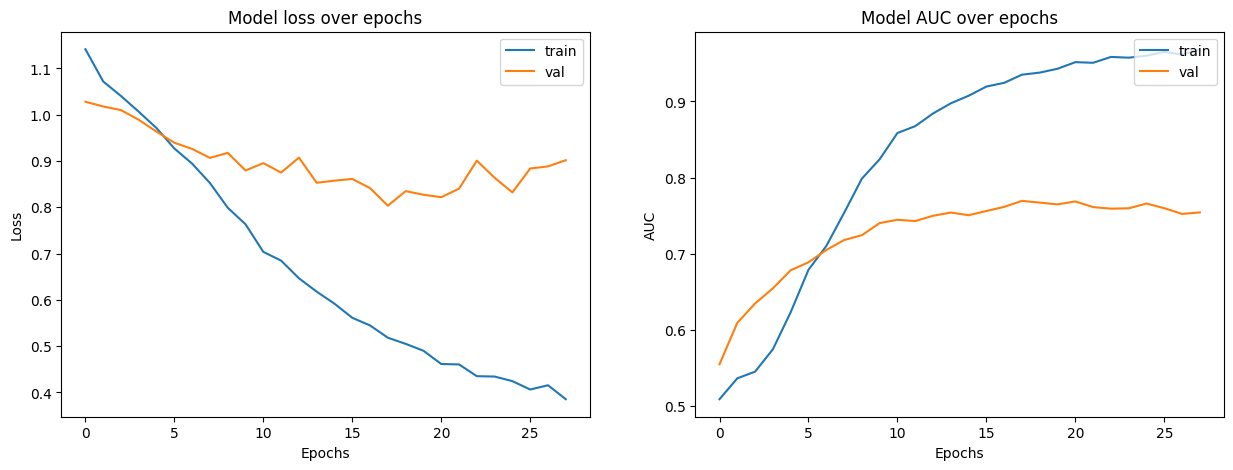

In [ ]:
plot_learning_curves(history_dnn)

In [ ]:
def predict_edge(node_id_1, node_id_2, node_features, model):
    if node_id_1 >= node_features.shape[0] or node_id_2 >= node_features.shape[0]:
        raise ValueError("Invalid node indices.")

    # Construct the input feature vector using concatenation
    edge_feature = np.hstack([node_features[node_id_1], node_features[node_id_2]])
    edge_feature = edge_feature.reshape(1, -1)

    # Make prediction
    prediction = model.predict(edge_feature)[0][0]
    print(f"Edge prediction probability between node {node_id_1} and {node_id_2}: {prediction:.4f}")

In [ ]:
predict_edge(1332, 159, node_features, dnn_model)

# Check if it exist in the positive edge:
if (1332, 159) in positive_edge_set or (159, 1332) in positive_edge_set:
    print("Ground truth: Edge actually exist in citation data.")
else:
    print("Ground truth: Edge does not exist in citation data.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Edge prediction probability between node 1332 and 159: 0.1516
Ground truth: Edge does not exist in citation data.


##  GNN-based edge prediction model

In [ ]:
# Extract node indices from feature matrices
def extract_indices(X, num_features=1433):
    source_indices = []
    target_indices = []
    for edge_features in X:
        source_features = edge_features[:num_features]
        target_features = edge_features[num_features:]
        source_index = np.where((node_features == source_features).all(axis=1))[0][0]
        target_index = np.where((node_features == target_features).all(axis=1))[0][0]
        source_indices.append(source_index)
        target_indices.append(target_index)
    return np.array(source_indices), np.array(target_indices)

# Get node indices for each split
train_source, train_target = extract_indices(X_train)
val_source, val_target = extract_indices(X_val)
test_source, test_target = extract_indices(X_test)

# Prepare adjacency matrix for GraphSAGE
num_nodes = node_features.shape[0]
adj_matrix = np.zeros((num_nodes, num_nodes), dtype=np.float32)
for src, tgt in positive_edges:
    adj_matrix[src, tgt] = 1.0
    adj_matrix[tgt, src] = 1.0

In [ ]:
class GraphSAGELayer(layers.Layer):
    def __init__(self, out_units, dropout_rate=0.3, **kwargs):
        super(GraphSAGELayer, self).__init__(**kwargs)
        self.out_units = out_units
        self.dropout_rate = dropout_rate

        self.aggregate_fn = layers.Dense(out_units,activation="relu",kernel_regularizer=keras.regularizers.l2(1e-4))
        self.update_fn = keras.Sequential([layers.Dense(out_units,activation="relu",kernel_regularizer=keras.regularizers.l2(1e-4)),layers.Dropout(dropout_rate)])

    def call(self, inputs):
        node_indices, node_features, adj_matrix = inputs

        neighbor_features = tf.gather(node_features, tf.cast(tf.math.argmax(tf.gather(adj_matrix, node_indices), axis=1), dtype=tf.int32))

        # Aggregate and update (using dense operations)
        aggregated = self.aggregate_fn(neighbor_features)
        combined = tf.concat([node_features, aggregated], axis=1)
        return self.update_fn(combined)


class GraphSAGE(keras.Model):
    def __init__(self, node_features, hidden_units, dropout_rate=0.5):
        super(GraphSAGE, self).__init__()
        self.node_features = tf.constant(node_features, dtype=tf.float32)
        self.num_nodes = node_features.shape[0]
        self.feature_dim = node_features.shape[1]

        # Initial projection
        self.feature_proj = layers.Dense(hidden_units[0],activation="relu",kernel_regularizer=keras.regularizers.l2(1e-4))


        # GraphSAGE layers
        self.sage_layers = []
        for units in hidden_units[1:]:
            self.sage_layers.append(
                GraphSAGELayer(units, dropout_rate=dropout_rate)
            )

        self.edge_predictor = keras.Sequential([
        layers.Dense(64, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid")
        ])

    def call(self, inputs):
        source_indices, target_indices = inputs

        # Get initial embeddings for all nodes
        node_embeddings = self.feature_proj(self.node_features)

        # Apply GraphSAGE layers
        for sage_layer in self.sage_layers:
            node_embeddings = sage_layer([
                tf.range(self.num_nodes),
                node_embeddings,
                adj_matrix
            ])

        # Gather embeddings for edge nodes
        source_emb = tf.gather(node_embeddings, source_indices)
        target_emb = tf.gather(node_embeddings, target_indices)

        # Predict edge existence
        edge_embeddings = tf.concat([source_emb, target_emb], axis=1)
        return self.edge_predictor(edge_embeddings)

# Hyperparameters
hidden_units = [32, 32]
dropout_rate = 0.4
batch_size =64
# Create model
gnn_model = GraphSAGE(node_features, hidden_units, dropout_rate)


In [ ]:
gnn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),loss='binary_crossentropy', metrics=[AUC(name='auc')])

In [ ]:
def create_dataset(sources, targets, labels, batch_size=64, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((
        (sources, targets),
        labels
    ))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(sources))
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_dataset = create_dataset(train_source, train_target, y_train, batch_size, True)
val_dataset = create_dataset(val_source, val_target, y_val, batch_size)
test_dataset = create_dataset(test_source, test_target, y_test, batch_size)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_gnn = gnn_model.fit(train_dataset, epochs=100,batch_size=128,validation_data=val_dataset, callbacks=[early_stopping])

Epoch 1/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - auc: 0.6255 - loss: 0.6791 - val_auc: 0.8256 - val_loss: 0.5772
Epoch 2/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.8521 - loss: 0.5310 - val_auc: 0.8407 - val_loss: 0.5778
Epoch 3/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.9183 - loss: 0.4407 - val_auc: 0.8613 - val_loss: 0.5561
Epoch 4/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.9366 - loss: 0.4112 - val_auc: 0.8565 - val_loss: 0.5914
Epoch 5/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.9524 - loss: 0.3806 - val_auc: 0.8608 - val_loss: 0.6023
Epoch 6/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9618 - loss: 0.3629 - val_auc: 0.8551 - val_loss: 0.6159
Epoch 7/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.9648 - loss: 0.3562 - val_auc: 0.8691 - val_loss: 0.6349
Epoch 8/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9733 - loss: 0.3313 - val_auc: 0.8518 - val_loss: 0.6702
Epoch 9/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3m

In [ ]:
# Evaluate on test set
test_loss, test_acc = gnn_model.evaluate(test_dataset)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8505 - loss: 0.5728
Test Loss: 0.568994402885437
Test Accuracy: 0.8529639840126038


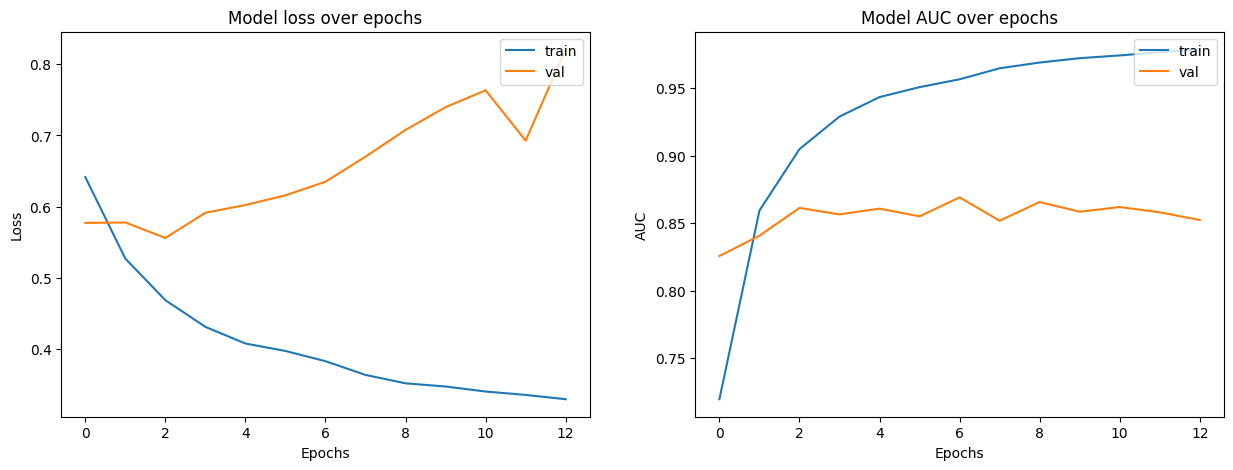

In [ ]:
plot_learning_curves(history_gnn)

In [ ]:
def predict_edge(node_id_1, node_id_2, node_features, model):
    if node_id_1 >= node_features.shape[0] or node_id_2 >= node_features.shape[0]:
        raise ValueError("Invalid node indices.")

    # Convert node IDs to TensorFlow tensors
    source_index = tf.constant([node_id_1], dtype=tf.int32)
    target_index = tf.constant([node_id_2], dtype=tf.int32)

    # Make prediction using the model's call method directly
    prediction = model((source_index, target_index)).numpy()[0][0]

    print(f"Edge prediction probability between node {node_id_1} and {node_id_2}: {prediction:.4f}")

In [ ]:
predict_edge(1332, 158, node_features, gnn_model)

# Check if it exist in the positive edge:
if (1332, 158) in positive_edge_set or (158, 1332) in positive_edge_set:
    print("Ground truth: Edge actually exist in citation data.")
else:
    print("Ground truth: Edge does not exist in citation data.")

Edge prediction probability between node 1332 and 158: 0.0227
Ground truth: Edge does not exist in citation data.


## Discussion

The GNN achieved a higher validation accuracy of approximately 0.83, outperforming the DNN which reached around 0.73. Additionally, the training curves reveal that the DNN suffered from significant overfitting, with the training loss approaching zero while the validation loss remained high and unstable throughout training. In contrast, the GNN demonstrated more stable and lower validation loss, indicating better generalization. This performance gain can be attributed to the GNN’s ability to utilize the underlying graph topology through neighborhood aggregation, allowing it to learn context-aware node representations. Unlike the DNN, which relies solely on static feature concatenation of node pairs, the GNN captures both local and global structural patterns in the graph. As a result, GNNs are better suited for edge prediction tasks where the relationship between nodes is influenced by their positions and connections within the graph.